# OW Yellow Caps — Notebook 1: Data Cleaning & Preprocessing

**Client:** OW Yellow Caps  
**Data:** NYC TLC Yellow Taxi Trip Records · January–March 2025  
**Purpose:** Validate, flag, and clean the raw dataset following TOR rules and course-slide principles.

## Framework Applied
The cleaning pipeline follows the eight quality dimensions required by the TOR (Appendix A):
1. Schema & field validity
2. Missingness (MCAR / MAR / MNAR assessment)
3. Temporal consistency
4. Cross-field logical consistency
5. Fare & payment consistency
6. Location validity
7. Duplicates & near-duplicates
8. Sensitivity analysis

Outlier detection uses: **IQR rule (Tukey)**, **Z-score**, and **Modified Z (MAD)** as taught in the *Responsible Outlier Detection* slides.

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

# ── Paths ──────────────────────────────────────────────────────────────────
RAW_PATH   = 'Project_master_clean.parquet'
CLEAN_PATH = 'yellow_taxi_clean.parquet'
FLAGGED_PATH = 'yellow_taxi_flagged_rows.parquet'
print('Libraries loaded.')

Libraries loaded.


---
## 1. Load Raw Data & Schema Review

In [39]:
df_raw = pd.read_parquet(RAW_PATH)

print(f'Shape: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Memory: {df_raw.memory_usage(deep=True).sum()/1e9:.2f} GB')
print('\nDtypes:')
print(df_raw.dtypes)
df_raw.head(3)

Shape: 11,198,026 rows × 22 columns
Memory: 2.86 GB

Dtypes:
trip_id                           int32
VendorID                          int32
tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
store_and_fwd_flag               object
PULocationID                      int32
DOLocationID                      int32
payment_type                      int32
fare_amount                     float64
extra                           float64
mta_tax                         float64
tip_amount                      float64
tolls_amount                    float64
improvement_surcharge           float64
total_amount                    float64
congestion_surcharge            float64
Airport_fee                     float64
cbd_congestion_fee              float64
source_month                     object
dtype: object


,trip_id,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,...,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee,source_month
0,1,1,2025-01-01 00:18:38,2025-01-01 00:26:59,1.0,1.6,1.0,N,229,237,...,3.5,0.5,3.00,0.0,1.0,18.00,2.5,0.0,0.0,2025-01
1,2,1,2025-01-01 00:32:40,2025-01-01 00:35:13,1.0,0.5,1.0,N,236,237,...,3.5,0.5,2.02,0.0,1.0,12.12,2.5,0.0,0.0,2025-01
2,3,1,2025-01-01 00:44:04,2025-01-01 00:46:01,1.0,0.6,1.0,N,141,141,...,3.5,0.5,2.00,0.0,1.0,12.10,2.5,0.0,0.0,2025-01


In [40]:
# ── Schema contract from TOR data dictionary ──────────────────────────────
SCHEMA_NOTES = """
Field              | Expected type | Valid values / constraints
-------------------+---------------+-------------------------------------------
trip_id            | int           | Row proxy (not original), positive
VendorID           | int           | {1, 2, 6, 7}
tpep_pickup_datetime  | datetime   | Jan–Mar 2025, < dropoff
tpep_dropoff_datetime | datetime   | Jan–Mar 2025, > pickup
passenger_count    | float/int     | 1–9 (null allowed for Flex Fare pt=0)
trip_distance      | float         | > 0, < 200 miles (realistic NYC cap)
RatecodeID         | float         | {1,2,3,4,5,6,99} (null for pt=0)
store_and_fwd_flag | str           | {'Y','N'}
PULocationID       | int           | 1–265 (TLC Taxi Zone)
DOLocationID       | int           | 1–265 (TLC Taxi Zone)
payment_type       | int           | {0,1,2,3,4,5,6}
fare_amount        | float         | >= 0 (refunds coded negative should be removed)
extra              | float         | >= 0
mta_tax            | float         | typically 0 or 0.5
tip_amount         | float         | >= 0 (auto-populated for credit card)
tolls_amount       | float         | >= 0
improvement_surcharge | float      | typically 0 or 1.0
total_amount       | float         | >= 0
congestion_surcharge  | float      | 0, 2.5, or 2.75
Airport_fee        | float         | 0, 1.75 (LGA), or 1.25 (JFK area)
cbd_congestion_fee | float         | 0 before 2025-01-05; >= 0 after
source_month       | str           | {'2025-01','2025-02','2025-03'}
"""
print(SCHEMA_NOTES)


Field              | Expected type | Valid values / constraints
-------------------+---------------+-------------------------------------------
trip_id            | int           | Row proxy (not original), positive
VendorID           | int           | {1, 2, 6, 7}
tpep_pickup_datetime  | datetime   | Jan–Mar 2025, < dropoff
tpep_dropoff_datetime | datetime   | Jan–Mar 2025, > pickup
passenger_count    | float/int     | 1–9 (null allowed for Flex Fare pt=0)
trip_distance      | float         | > 0, < 200 miles (realistic NYC cap)
RatecodeID         | float         | {1,2,3,4,5,6,99} (null for pt=0)
store_and_fwd_flag | str           | {'Y','N'}
PULocationID       | int           | 1–265 (TLC Taxi Zone)
DOLocationID       | int           | 1–265 (TLC Taxi Zone)
payment_type       | int           | {0,1,2,3,4,5,6}
fare_amount        | float         | >= 0 (refunds coded negative should be removed)
extra              | float         | >= 0
mta_tax            | float         | typically 0

---
## 2. Before-Cleaning Snapshot (Raw Quality Metrics)

In [41]:
df = df_raw.copy()
n_raw = len(df)
print(f'Raw rows: {n_raw:,}')

# Missing values
miss = df.isnull().sum()
miss_pct = 100 * miss / n_raw
miss_df = pd.DataFrame({'missing_count': miss, 'missing_%': miss_pct.round(2)})
miss_df = miss_df[miss_df.missing_count > 0]
print('\n== Missing Values ==')
print(miss_df.to_string())

Raw rows: 11,198,026

== Missing Values ==
                      missing_count  missing_%
passenger_count             2263749      20.22
RatecodeID                  2263749      20.22
store_and_fwd_flag          2263749      20.22
congestion_surcharge        2263749      20.22
Airport_fee                 2263749      20.22


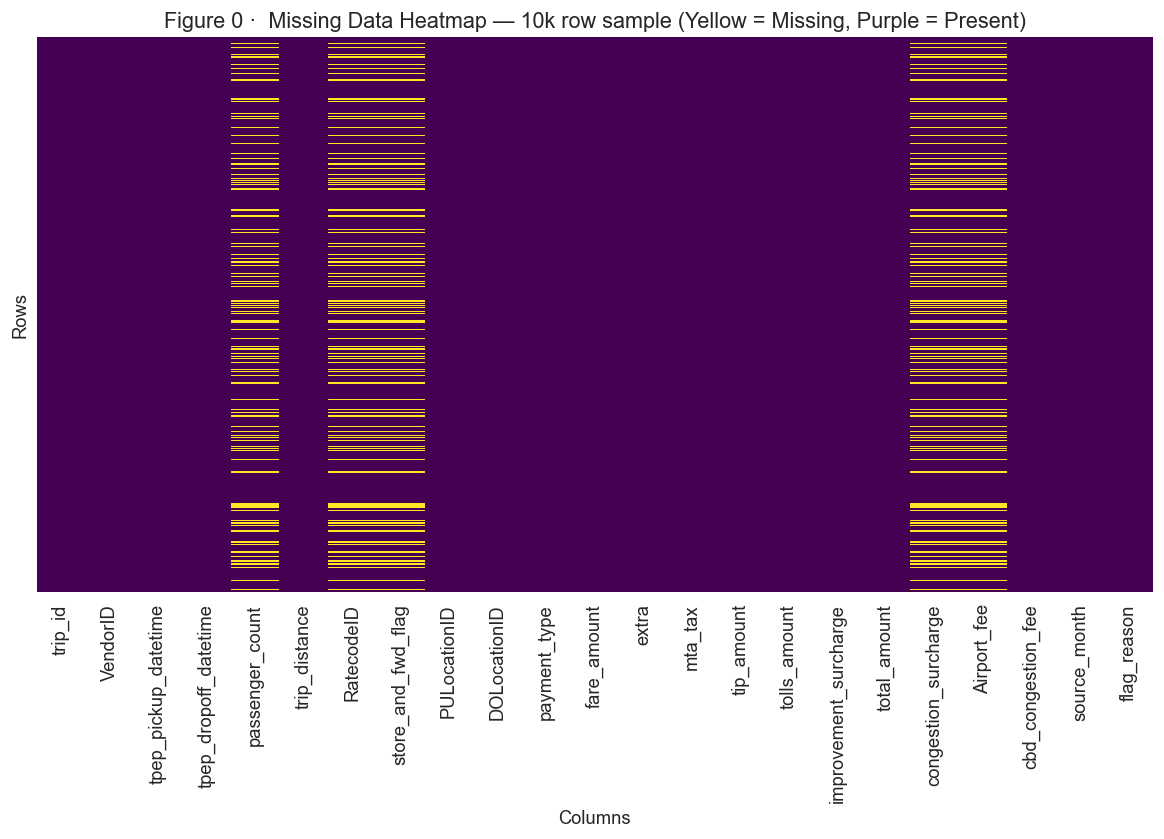

In [69]:
sample = df.sample(n=10_000, random_state=42) if len(df) > 10_000 else df

plt.figure(figsize=(12, 6))
sns.heatmap(sample.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title("Figure 0 ·  Missing Data Heatmap — 10k row sample (Yellow = Missing, Purple = Present)")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

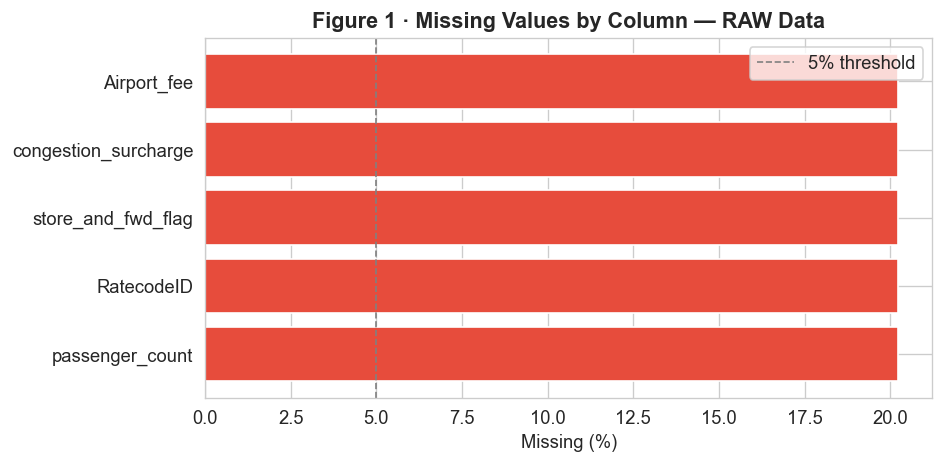

In [43]:
# ── Missing value bar chart (Before Cleaning) ──────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
miss_plot = miss_df[miss_df.missing_count > 0]
colors = ['#e74c3c' if p > 10 else '#f39c12' for p in miss_plot['missing_%']]
ax.barh(miss_plot.index, miss_plot['missing_%'], color=colors)
ax.axvline(5, color='grey', linestyle='--', lw=1, label='5% threshold')
ax.set_xlabel('Missing (%)')
ax.set_title('Figure 1 · Missing Values by Column — RAW Data', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

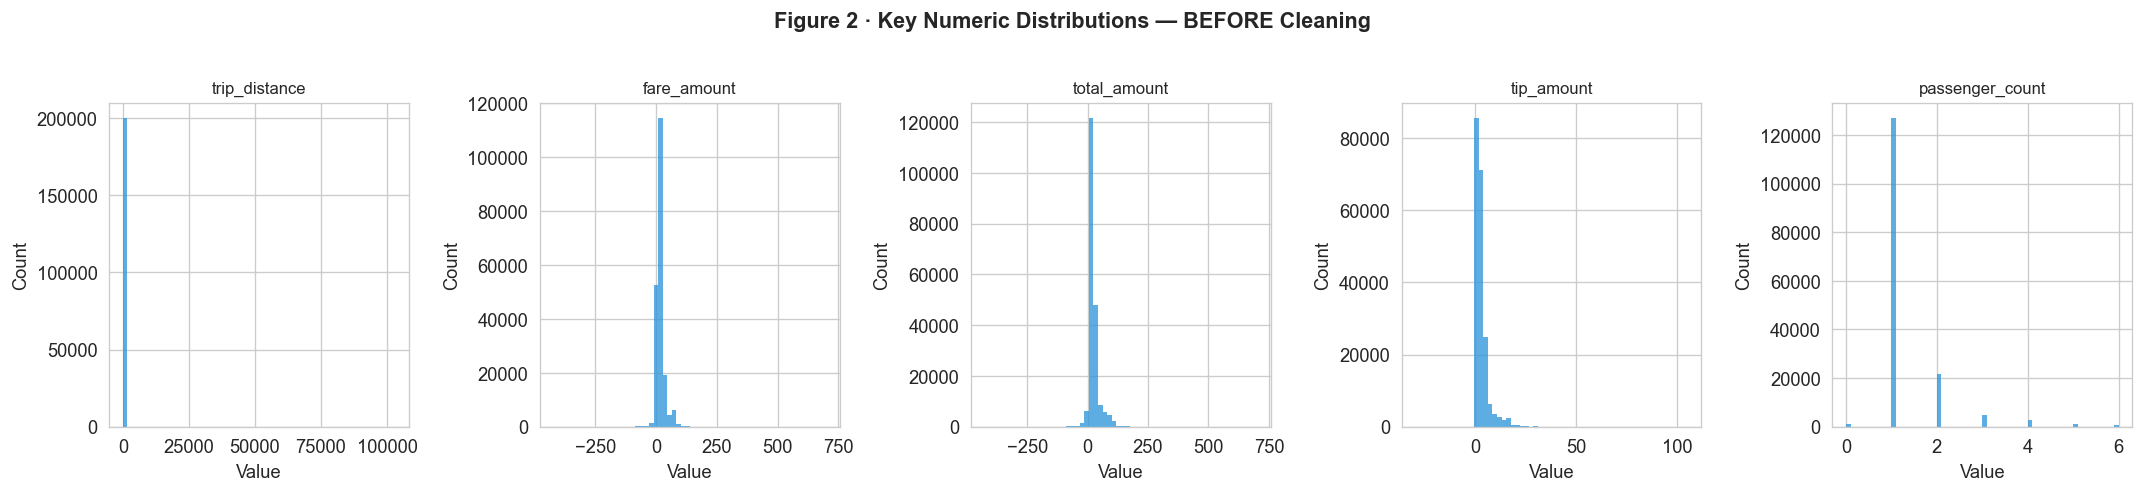

Note: extreme x-axis ranges reveal serious data quality issues.


In [44]:
# ── Numeric distributions BEFORE cleaning (sample 200k for speed) ─────────
numeric_cols = ['trip_distance', 'fare_amount', 'total_amount', 'tip_amount', 'passenger_count']
sample = df[numeric_cols].sample(200_000, random_state=42)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    ax.hist(sample[col].dropna(), bins=60, color='#3498db', edgecolor='none', alpha=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')
fig.suptitle('Figure 2 · Key Numeric Distributions — BEFORE Cleaning', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print('Note: extreme x-axis ranges reveal serious data quality issues.')

---
## 3. Step-by-Step Cleaning Pipeline

> Each step logs how many rows are **removed** and why. A `flag_reason` column tracks all issues found.

In [ ]:
# ── Audit log ─────────────────────────────────────────────────────────────
audit = []   # list of dicts: {step, rule, n_flagged, action}
df['flag_reason'] = ''  # accumulates reason tags

def log_flag(df, mask, reason, action='removed'):
    """Add flag to mask rows and log to audit."""
    n = mask.sum()
    df.loc[mask, 'flag_reason'] = df.loc[mask, 'flag_reason'].apply(
        lambda x: x + ('|' if x else '') + reason
    )
    audit.append({'step': reason, 'n_flagged': n, 'action': action,
                  'pct_of_raw': round(100*n/n_raw, 3)})
    return n

print('Audit framework ready.')

Audit framework ready.


: 

In [46]:
# ── 3.1 · TEMPORAL VALIDITY ───────────────────────────────────────────────
# Rule: pickup must be within Jan–Mar 2025 (scope of the project)
SCOPE_START = pd.Timestamp('2025-01-01')
SCOPE_END   = pd.Timestamp('2025-03-31 23:59:59')

out_of_scope = ~((df.tpep_pickup_datetime >= SCOPE_START) &
                 (df.tpep_pickup_datetime <= SCOPE_END))
n = log_flag(df, out_of_scope, 'out_of_scope_date')
print(f'3.1 Out-of-scope pickup dates: {n:,} rows')

# Rule: dropoff must not precede pickup (negative duration)
neg_dur = (df.tpep_dropoff_datetime < df.tpep_pickup_datetime) & ~out_of_scope
n = log_flag(df, neg_dur, 'negative_duration')
print(f'3.1 Negative trip duration (dropoff < pickup): {n:,} rows')

# Rule: zero-second trips (meter engaged and disengaged at same moment)
zero_dur = (df.tpep_dropoff_datetime == df.tpep_pickup_datetime) & ~out_of_scope & ~neg_dur
n = log_flag(df, zero_dur, 'zero_duration')
print(f'3.1 Zero duration trips: {n:,} rows')

# Rule: implausibly long trips > 24 hours (flagged but retained for sensitivity)
dur_hours = (df.tpep_dropoff_datetime - df.tpep_pickup_datetime).dt.total_seconds() / 3600
long_trip = (dur_hours > 24) & ~out_of_scope & ~neg_dur & ~zero_dur
n = log_flag(df, long_trip, 'duration_gt_24h', action='flagged_kept')
print(f'3.1 Duration > 24 hours (flagged, kept): {n:,} rows')

3.1 Out-of-scope pickup dates: 25 rows
3.1 Negative trip duration (dropoff < pickup): 298 rows
3.1 Zero duration trips: 29,197 rows
3.1 Duration > 24 hours (flagged, kept): 47 rows


In [47]:
# ── 3.2 · FIELD VALIDITY ─────────────────────────────────────────────────
# VendorID: valid = {1, 2, 6, 7} per TOR dictionary
valid_vendor = {1, 2, 6, 7}
bad_vendor = ~df.VendorID.isin(valid_vendor)
n = log_flag(df, bad_vendor, 'invalid_VendorID')
print(f'3.2 Invalid VendorID: {n:,} rows')
print('   VendorID distribution:', df.VendorID.value_counts().to_dict())

# RatecodeID: valid = {1,2,3,4,5,6,99} per TOR dictionary
valid_rate = {1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 99.0}
# NaN allowed only for Flex Fare (payment_type == 0)
bad_rate = (~df.RatecodeID.isin(valid_rate)) & ~(df.RatecodeID.isnull() & (df.payment_type == 0))
n = log_flag(df, bad_rate, 'invalid_RatecodeID')
print(f'3.2 Invalid RatecodeID (excl. Flex Fare nulls): {n:,} rows')

# payment_type: valid = {0,1,2,3,4,5,6}
valid_pt = {0, 1, 2, 3, 4, 5, 6}
bad_pt = ~df.payment_type.isin(valid_pt)
n = log_flag(df, bad_pt, 'invalid_payment_type')
print(f'3.2 Invalid payment_type: {n:,} rows')

# store_and_fwd_flag: valid = {'Y', 'N'}
bad_flag = ~df.store_and_fwd_flag.isin(['Y', 'N'])
n = log_flag(df, bad_flag, 'invalid_store_fwd_flag')
print(f'3.2 Invalid store_and_fwd_flag: {n:,} rows')

3.2 Invalid VendorID: 0 rows
   VendorID distribution: {2: 8826711, 1: 2343055, 7: 27107, 6: 1153}
3.2 Invalid RatecodeID (excl. Flex Fare nulls): 0 rows
3.2 Invalid payment_type: 0 rows
3.2 Invalid store_and_fwd_flag: 2,263,749 rows


In [48]:
# ── 3.3 · LOCATION VALIDITY ──────────────────────────────────────────────
# TLC zones: 1–265 are valid pickup/dropoff zone IDs
bad_pu = (df.PULocationID < 1) | (df.PULocationID > 265)
bad_do = (df.DOLocationID < 1) | (df.DOLocationID > 265)
bad_loc = bad_pu | bad_do
n = log_flag(df, bad_loc, 'invalid_location_id')
print(f'3.3 Invalid PU/DO LocationID: {n:,} rows')
print(f'  PU range: {df.PULocationID.min()}–{df.PULocationID.max()}')
print(f'  DO range: {df.DOLocationID.min()}–{df.DOLocationID.max()}')

3.3 Invalid PU/DO LocationID: 0 rows
  PU range: 1–265
  DO range: 1–265


In [49]:
# ── 3.4 · NUMERIC RANGE VALIDITY ─────────────────────────────────────────
# Negative fares (excluding payment_type 3=NoCharge and 4=Dispute)
neg_fare = (df.fare_amount < 0) & ~df.payment_type.isin([3, 4])
n = log_flag(df, neg_fare, 'negative_fare_amount')
print(f'3.4 Negative fare_amount (excl. dispute/no-charge): {n:,}')

neg_total = (df.total_amount < 0) & ~df.payment_type.isin([3, 4])
n = log_flag(df, neg_total, 'negative_total_amount')
print(f'3.4 Negative total_amount (excl. dispute/no-charge): {n:,}')

neg_tip = df.tip_amount < 0
n = log_flag(df, neg_tip, 'negative_tip_amount')
print(f'3.4 Negative tip_amount: {n:,}')

neg_tolls = df.tolls_amount < 0
n = log_flag(df, neg_tolls, 'negative_tolls_amount')
print(f'3.4 Negative tolls_amount: {n:,}')

# Trip distance: <= 0 is impossible; > 200 miles is implausible for NYC taxi
dist_zero = df.trip_distance <= 0
n = log_flag(df, dist_zero, 'trip_distance_le_0')
print(f'3.4 trip_distance <= 0: {n:,}')

dist_extreme = df.trip_distance > 200
n = log_flag(df, dist_extreme, 'trip_distance_gt_200mi')
print(f'3.4 trip_distance > 200 miles: {n:,}')

# Passenger count: 0 or > 9 is invalid (nulls for Flex Fare are OK)
bad_pax = (df.passenger_count.notna()) & ((df.passenger_count < 1) | (df.passenger_count > 9))
n = log_flag(df, bad_pax, 'invalid_passenger_count')
print(f'3.4 Invalid passenger_count (0 or >9, excl. nulls): {n:,}')

3.4 Negative fare_amount (excl. dispute/no-charge): 396,565
3.4 Negative total_amount (excl. dispute/no-charge): 47,913
3.4 Negative tip_amount: 360
3.4 Negative tolls_amount: 14,394
3.4 trip_distance <= 0: 294,386
3.4 trip_distance > 200 miles: 452
3.4 Invalid passenger_count (0 or >9, excl. nulls): 69,122


In [50]:
# ── 3.5 · CROSS-FIELD LOGICAL CONSISTENCY ────────────────────────────────
# CBD Congestion Fee: must be 0 before January 5, 2025 (per TOR)
CBD_START = pd.Timestamp('2025-01-05')
cbd_before_start = (df.tpep_pickup_datetime < CBD_START) & (df.cbd_congestion_fee > 0)
n = log_flag(df, cbd_before_start, 'cbd_fee_before_jan5')
print(f'3.5 CBD fee > 0 before Jan 5 2025: {n:,} rows')

# Airport fee: should only apply to pickups at LGA (zone 138) or JFK (zone 132)
# Non-zero airport fee for non-airport pickup is a logical inconsistency
AIRPORT_ZONES = {132, 138}  # JFK, LGA
bad_airport = (df.Airport_fee > 0) & (~df.PULocationID.isin(AIRPORT_ZONES))
n = log_flag(df, bad_airport, 'airport_fee_non_airport_pu', action='flagged_kept')
print(f'3.5 Airport fee > 0 for non-airport pickup (flagged, kept): {n:,}')

# tip_amount should be 0 for non-credit-card payments (payment_type != 1)
# Per data dictionary: tip_amount auto-populated ONLY for credit card
tip_non_cc = (df.tip_amount > 0) & (df.payment_type != 1)
n = log_flag(df, tip_non_cc, 'tip_on_non_cc_payment', action='flagged_kept')
print(f'3.5 Tip > 0 on non-credit-card payment (flagged, kept): {n:,}')

# total_amount should be >= fare_amount (it includes all surcharges)
total_lt_fare = (df.total_amount < df.fare_amount) & (df.fare_amount > 0)
n = log_flag(df, total_lt_fare, 'total_lt_fare', action='flagged_kept')
print(f'3.5 total_amount < fare_amount (flagged, kept): {n:,}')

3.5 CBD fee > 0 before Jan 5 2025: 402 rows
3.5 Airport fee > 0 for non-airport pickup (flagged, kept): 24,879
3.5 Tip > 0 on non-credit-card payment (flagged, kept): 193,564
3.5 total_amount < fare_amount (flagged, kept): 94


In [51]:
# ── 3.6 · MISSINGNESS ANALYSIS ────────────────────────────────────────────
# From the Missing Data slides: classify as MCAR, MAR, or MNAR
print('=== Missing Data Mechanism Classification ===')
print()
print('passenger_count null:', df.passenger_count.isnull().sum(), '→ only when payment_type=0 (Flex Fare)')
print('RatecodeID null:     ', df.RatecodeID.isnull().sum(), '→ only when payment_type=0 (Flex Fare)')
print()
print('Mechanism: MAR (Missing At Random) — both fields are null SYSTEMATICALLY')
print('for all Flex Fare trips (payment_type=0). The missingness is fully explained')
print('by payment_type, which is observed. Not MCAR (not random), not MNAR')
print('(not hidden). Action: RETAIN these rows; exclude fields when analysing')
print('non-Flex-Fare trips if needed.')

# Verify the MAR claim quantitatively
pt0_rows = df.payment_type == 0
assert df.passenger_count.isnull().sum() == pt0_rows.sum(), 'MAR claim violated'
print()
print('MAR claim verified: ALL passenger_count nulls are exactly the Flex Fare rows.')

=== Missing Data Mechanism Classification ===

passenger_count null: 2263749 → only when payment_type=0 (Flex Fare)
RatecodeID null:      2263749 → only when payment_type=0 (Flex Fare)

Mechanism: MAR (Missing At Random) — both fields are null SYSTEMATICALLY
for all Flex Fare trips (payment_type=0). The missingness is fully explained
by payment_type, which is observed. Not MCAR (not random), not MNAR
(not hidden). Action: RETAIN these rows; exclude fields when analysing
non-Flex-Fare trips if needed.

MAR claim verified: ALL passenger_count nulls are exactly the Flex Fare rows.


In [52]:
# ── 3.7 · OUTLIER DETECTION (from Responsible Outlier Detection slides) ───
# Applied to: trip_distance, fare_amount, total_amount
# Methods: IQR (Tukey), Z-score, Modified Z (MAD)
# Outliers are FLAGGED, not automatically deleted — per slide principle:
# 'Outliers are flags, not verdicts.'

def iqr_outliers(series, k=1.5):
    """Tukey IQR rule: flags values < Q1-k*IQR or > Q3+k*IQR."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR = Q3 - Q1
    return (series < Q1 - k * IQR) | (series > Q3 + k * IQR)

def zscore_outliers(series, threshold=3.0):
    """Standard Z-score: |z| > threshold."""
    z = (series - series.mean()) / series.std()
    return z.abs() > threshold

def modified_zscore_outliers(series, threshold=3.5):
    """Modified Z (Iglewicz & Hoaglin 1993) using MAD — robust to skew.
    From the outlier detection slides: M_i = 0.6745*(x_i - median) / MAD
    Flag if |M_i| > 3.5
    """
    median = series.median()
    mad = (series - median).abs().median()
    if mad == 0:
        return pd.Series(False, index=series.index)
    M = 0.6745 * (series - median) / mad
    return M.abs() > threshold

# Work only on the portion NOT already flagged for removal
# (we detect outliers in 'good' records only — domain-invalid rows excluded)
HARD_REMOVE_FLAGS = [
    'out_of_scope_date', 'negative_duration', 'zero_duration',
    'invalid_VendorID', 'invalid_payment_type',
    'negative_fare_amount', 'negative_total_amount',
    'trip_distance_le_0', 'trip_distance_gt_200mi',
    'invalid_passenger_count', 'cbd_fee_before_jan5'
]

def is_hard_flagged(df):
    return df.flag_reason.apply(
        lambda r: any(f in r for f in HARD_REMOVE_FLAGS)
    )

mask_keep = ~is_hard_flagged(df)
print(f'Rows passing hard checks (for outlier analysis): {mask_keep.sum():,}')

Rows passing hard checks (for outlier analysis): 10,449,349


In [53]:
# ── Apply all three outlier methods to trip_distance ──────────────────────
clean_sub = df.loc[mask_keep, 'trip_distance']

iqr_out_dist   = iqr_outliers(clean_sub, k=3.0)    # k=3 for 'extreme' per slides
z_out_dist     = zscore_outliers(clean_sub, 3.0)
mz_out_dist    = modified_zscore_outliers(clean_sub, 3.5)

print('=== trip_distance outlier summary ===')
print(f'  IQR (k=3):       {iqr_out_dist.sum():>8,} ({100*iqr_out_dist.mean():.2f}%)')
print(f'  Z-score (|z|>3): {z_out_dist.sum():>8,} ({100*z_out_dist.mean():.2f}%)')
print(f'  Modified Z (MAD):{mz_out_dist.sum():>8,} ({100*mz_out_dist.mean():.2f}%)')

# Agreement among methods
consensus_dist = iqr_out_dist & z_out_dist & mz_out_dist
print(f'  All three agree: {consensus_dist.sum():>8,} ({100*consensus_dist.mean():.2f}%)')

# Flag the consensus extreme outliers (flag only, not removed)
extreme_dist = pd.Series(False, index=df.index)
extreme_dist.loc[mask_keep[mask_keep].index] = consensus_dist.values
n = log_flag(df, extreme_dist, 'extreme_outlier_distance', action='flagged_kept')
print(f'\nFlagged as extreme distance outlier (all 3 methods): {n:,}')

=== trip_distance outlier summary ===
  IQR (k=3):        716,377 (6.86%)
  Z-score (|z|>3):  388,574 (3.72%)
  Modified Z (MAD):1,329,970 (12.73%)
  All three agree:  388,574 (3.72%)

Flagged as extreme distance outlier (all 3 methods): 388,574


In [54]:
# ── Apply all three methods to fare_amount ────────────────────────────────
clean_fare = df.loc[mask_keep, 'fare_amount']

iqr_out_fare  = iqr_outliers(clean_fare, k=3.0)
z_out_fare    = zscore_outliers(clean_fare, 3.0)
mz_out_fare   = modified_zscore_outliers(clean_fare, 3.5)

print('=== fare_amount outlier summary ===')
print(f'  IQR (k=3):       {iqr_out_fare.sum():>8,} ({100*iqr_out_fare.mean():.2f}%)')
print(f'  Z-score (|z|>3): {z_out_fare.sum():>8,} ({100*z_out_fare.mean():.2f}%)')
print(f'  Modified Z (MAD):{mz_out_fare.sum():>8,} ({100*mz_out_fare.mean():.2f}%)')

consensus_fare = iqr_out_fare & z_out_fare & mz_out_fare
print(f'  All three agree: {consensus_fare.sum():>8,} ({100*consensus_fare.mean():.2f}%)')

extreme_fare = pd.Series(False, index=df.index)
extreme_fare.loc[mask_keep[mask_keep].index] = consensus_fare.values
n = log_flag(df, extreme_fare, 'extreme_outlier_fare', action='flagged_kept')
print(f'\nFlagged extreme fare outlier (all 3 methods agree): {n:,}')

=== fare_amount outlier summary ===
  IQR (k=3):        525,225 (5.03%)
  Z-score (|z|>3):       20 (0.00%)
  Modified Z (MAD): 935,898 (8.96%)
  All three agree:       20 (0.00%)

Flagged extreme fare outlier (all 3 methods agree): 20


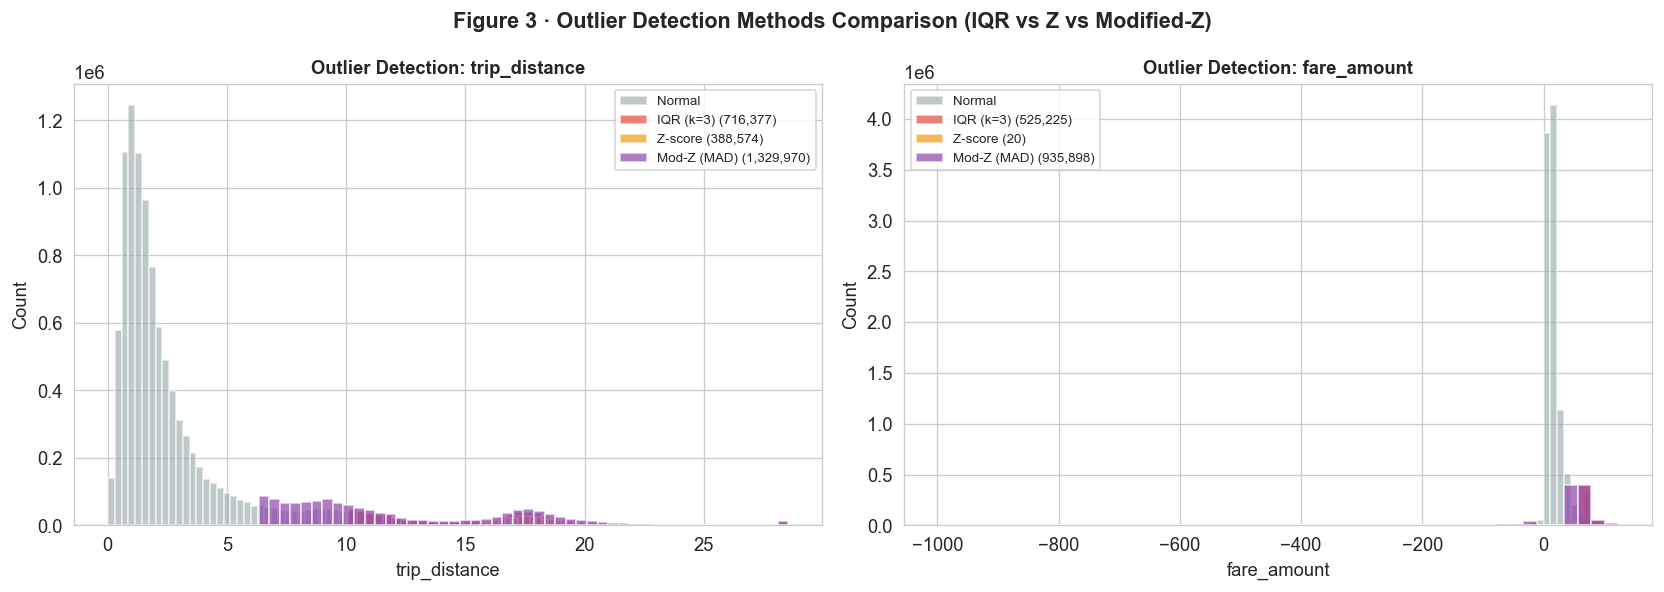

In [56]:
# ── Outlier comparison visualization ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, iqr_m, z_m, mz_m in [
    (axes[0], 'trip_distance', iqr_out_dist, z_out_dist, mz_out_dist),
    (axes[1], 'fare_amount',   iqr_out_fare, z_out_fare, mz_out_fare)
]:
    vals = df.loc[mask_keep, col]
    # Clip for visibility
    clip = vals.quantile(0.999)
    vals_clip = vals.clip(upper=clip)
    ax.hist(vals_clip, bins=100, color='#95a5a6', alpha=0.6, label='Normal')
    
    methods = {'IQR (k=3)': iqr_m, 'Z-score': z_m, 'Mod-Z (MAD)': mz_m}
    colors  = ['#e74c3c', '#f39c12', '#8e44ad']
    for (name, mask), c in zip(methods.items(), colors):
        out_vals = vals[mask].clip(upper=clip)
        ax.hist(out_vals, bins=50, color=c, alpha=0.7, label=f'{name} ({mask.sum():,})')
    
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.set_title(f'Outlier Detection: {col}', fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)

fig.suptitle('Figure 3 · Outlier Detection Methods Comparison (IQR vs Z vs Modified-Z)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [57]:
# ── 3.8 · DUPLICATE DETECTION ─────────────────────────────────────────────
# Near-duplicates: same key financial and location fields suggests double submission
dup_cols = ['tpep_pickup_datetime', 'PULocationID', 'DOLocationID',
            'fare_amount', 'trip_distance', 'payment_type']

# Keep first occurrence, flag the rest
dup_mask = df.duplicated(subset=dup_cols, keep='first')
n = log_flag(df, dup_mask, 'duplicate_trip')
print(f'3.8 Duplicate trips (same datetime+location+fare+distance+payment): {n:,}')
print(f'    Percentage of raw: {100*n/n_raw:.2f}%')

3.8 Duplicate trips (same datetime+location+fare+distance+payment): 1,067
    Percentage of raw: 0.01%


---
## 4. Build Cleaned Dataset

In [58]:
# ── Audit summary ─────────────────────────────────────────────────────────
audit_df = pd.DataFrame(audit)
print('=== FULL AUDIT REPORT ===')
print(audit_df.to_string(index=False))

removed = audit_df[audit_df.action == 'removed']['n_flagged'].sum()
flagged_kept = audit_df[audit_df.action == 'flagged_kept']['n_flagged'].sum()
print(f'\nTotal rows hard-removed: {removed:,} ({100*removed/n_raw:.2f}%)')
print(f'Total rows flagged-kept: {flagged_kept:,}')

=== FULL AUDIT REPORT ===
                      step  n_flagged       action  pct_of_raw
         out_of_scope_date         25      removed       0.000
         negative_duration        298      removed       0.003
             zero_duration      29197      removed       0.261
           duration_gt_24h         47 flagged_kept       0.000
          invalid_VendorID          0      removed       0.000
        invalid_RatecodeID          0      removed       0.000
      invalid_payment_type          0      removed       0.000
    invalid_store_fwd_flag    2263749      removed      20.216
       invalid_location_id          0      removed       0.000
      negative_fare_amount     396565      removed       3.541
     negative_total_amount      47913      removed       0.428
       negative_tip_amount        360      removed       0.003
     negative_tolls_amount      14394      removed       0.129
        trip_distance_le_0     294386      removed       2.629
    trip_distance_gt_200mi   

In [59]:
# ── Hard-remove flagged rows ──────────────────────────────────────────────
hard_remove_mask = is_hard_flagged(df) | (df.flag_reason.str.contains('duplicate_trip'))

df_flagged = df[hard_remove_mask].copy()   # save removed rows for reference
df_clean   = df[~hard_remove_mask].copy()

# Derive useful engineered features on clean data
df_clean['trip_duration_min'] = (
    (df_clean.tpep_dropoff_datetime - df_clean.tpep_pickup_datetime)
    .dt.total_seconds() / 60
).round(2)
df_clean['pickup_hour']    = df_clean.tpep_pickup_datetime.dt.hour
df_clean['pickup_dow']     = df_clean.tpep_pickup_datetime.dt.dayofweek  # 0=Mon
df_clean['pickup_dow_name']= df_clean.tpep_pickup_datetime.dt.day_name()
df_clean['pickup_date']    = df_clean.tpep_pickup_datetime.dt.date
df_clean['pickup_month']   = df_clean.tpep_pickup_datetime.dt.month
df_clean['pickup_week']    = df_clean.tpep_pickup_datetime.dt.isocalendar().week.astype(int)
df_clean['is_weekend']     = df_clean.pickup_dow >= 5
df_clean['is_post_cbd']    = df_clean.tpep_pickup_datetime >= pd.Timestamp('2025-01-05')
df_clean['speed_mph']      = (df_clean.trip_distance / (df_clean.trip_duration_min / 60)).round(2)

print(f'Clean dataset shape: {df_clean.shape}')
print(f'Removed rows saved: {df_flagged.shape}')

Clean dataset shape: (10448657, 33)
Removed rows saved: (749369, 23)


In [60]:
# ── Save outputs ──────────────────────────────────────────────────────────
df_clean.to_parquet(CLEAN_PATH, index=False)
df_flagged.to_parquet(FLAGGED_PATH, index=False)
print(f'Clean data saved to: {CLEAN_PATH}')
print(f'Flagged rows saved to: {FLAGGED_PATH}')

Clean data saved to: yellow_taxi_clean.parquet
Flagged rows saved to: yellow_taxi_flagged_rows.parquet


---
## 5. After-Cleaning Snapshot

In [61]:
n_clean = len(df_clean)
print(f'Raw rows:   {n_raw:>12,}')
print(f'Clean rows: {n_clean:>12,}')
print(f'Removed:    {n_raw - n_clean:>12,} ({100*(n_raw-n_clean)/n_raw:.2f}%)')
print()

# Post-cleaning stats
for col in ['trip_distance', 'fare_amount', 'total_amount', 'trip_duration_min']:
    s = df_clean[col]
    print(f'{col:25s}: min={s.min():8.2f}  median={s.median():8.2f}  '
          f'mean={s.mean():8.2f}  max={s.max():10.2f}')

Raw rows:     11,198,026
Clean rows:   10,448,657
Removed:         749,369 (6.69%)

trip_distance            : min=    0.01  median=    1.76  mean=    3.23  max=    199.30
fare_amount              : min= -999.00  median=   13.43  mean=   18.05  max= 863372.12
total_amount             : min=-1000.00  median=   20.70  mean=   26.60  max= 863380.37
trip_duration_min        : min=    0.02  median=   12.12  mean=   15.64  max=   8564.67


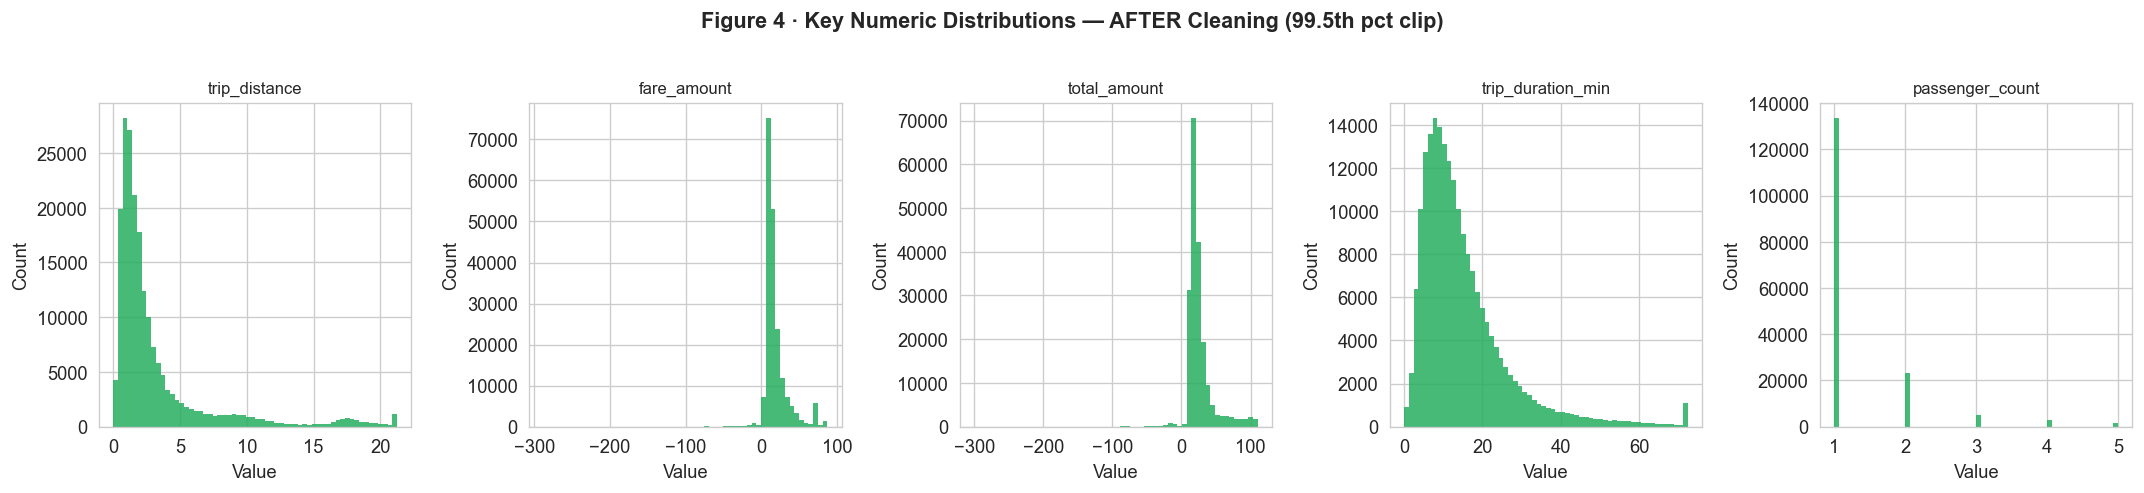

In [63]:
# ── After-cleaning distributions ─────────────────────────────────────────
numeric_cols = ['trip_distance', 'fare_amount', 'total_amount',
                'trip_duration_min', 'passenger_count']
sample_clean = df_clean[numeric_cols].sample(min(200_000, len(df_clean)), random_state=42)

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    data = sample_clean[col].dropna()
    clip = data.quantile(0.995)
    ax.hist(data.clip(upper=clip), bins=60, color='#27ae60', edgecolor='none', alpha=0.85)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Count')

fig.suptitle('Figure 4 · Key Numeric Distributions — AFTER Cleaning (99.5th pct clip)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

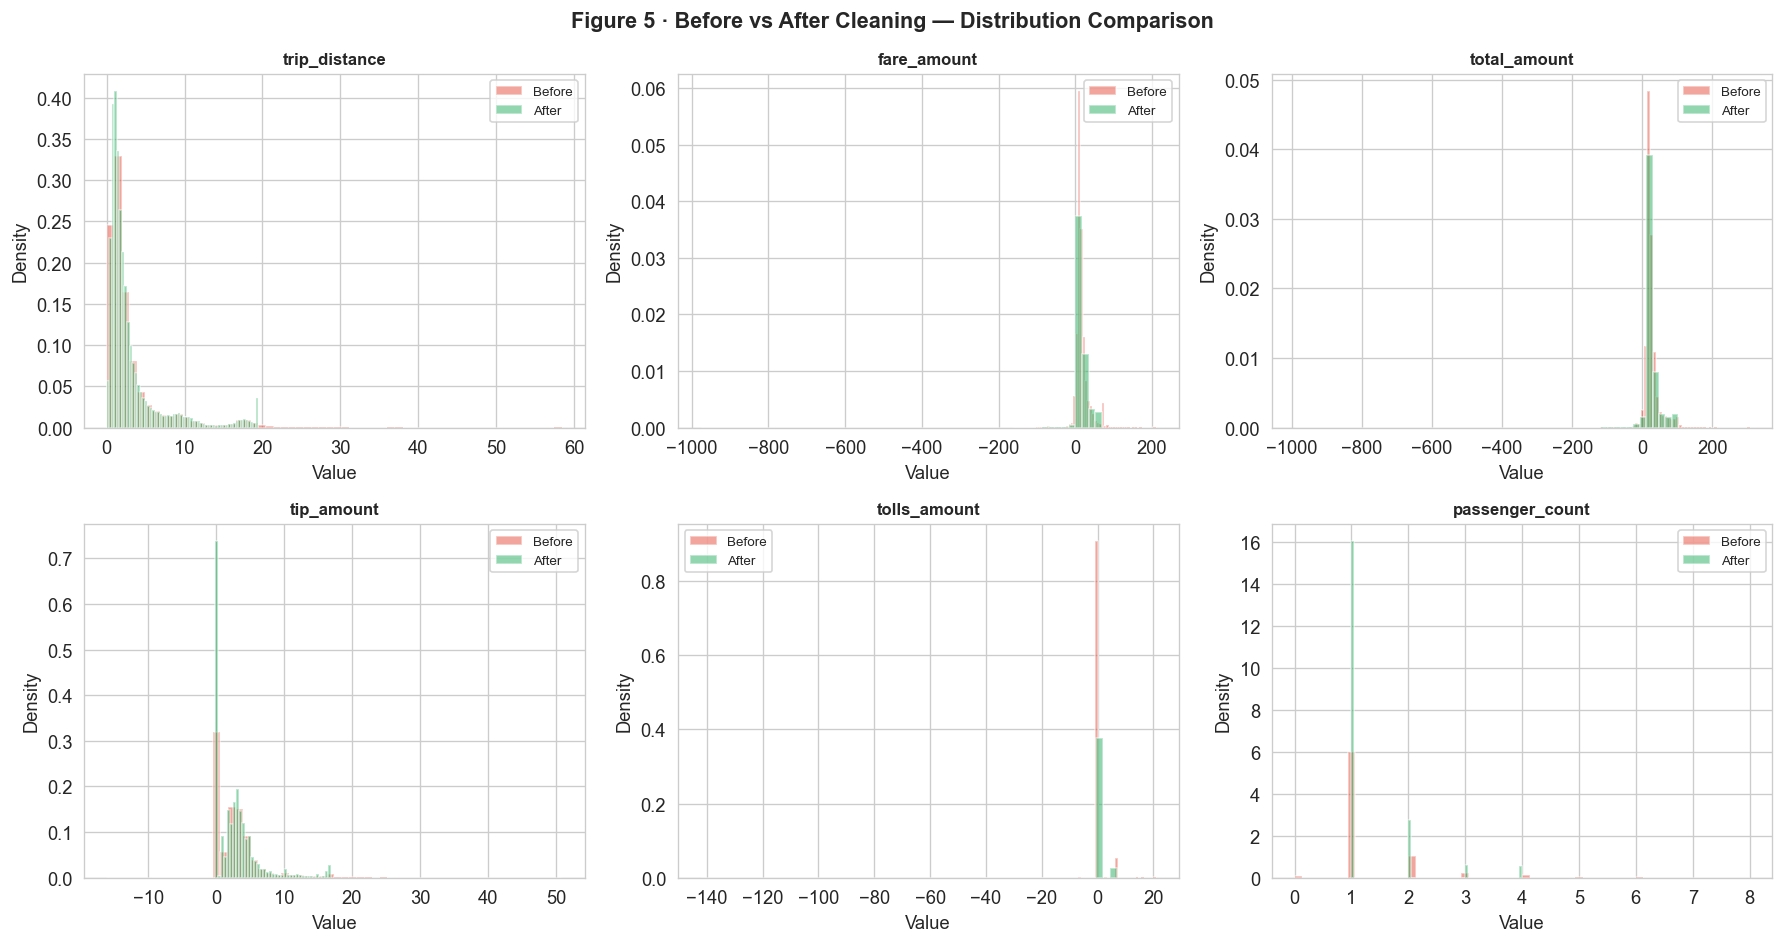

In [64]:
# ── Before vs After comparison plot ──────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

cols_compare = ['trip_distance', 'fare_amount', 'total_amount',
                'tip_amount', 'tolls_amount', 'passenger_count']

for ax, col in zip(axes, cols_compare):
    before = df[col].sample(min(100_000, len(df)), random_state=1)
    after  = df_clean[col].sample(min(100_000, len(df_clean)), random_state=1)
    clip_val = after.quantile(0.99) if after.quantile(0.99) > 0 else after.max()
    
    ax.hist(before.clip(upper=clip_val * 3).dropna(), bins=60,
            color='#e74c3c', alpha=0.5, label='Before', density=True)
    ax.hist(after.clip(upper=clip_val).dropna(), bins=60,
            color='#27ae60', alpha=0.5, label='After', density=True)
    ax.set_title(col, fontsize=10, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

fig.suptitle('Figure 5 · Before vs After Cleaning — Distribution Comparison',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Sensitivity Analysis

> TOR Appendix A: *"Each group must include at least one short sensitivity analysis showing whether a reasonable alternative cleaning decision materially changes the headline business conclusions."*

In [65]:
# ── Sensitivity: does keeping zero-duration trips change the median fare? ──
base_median_fare    = df_clean.fare_amount.median()
# Alternative: keep zero-duration trips
alt_clean = df[~is_hard_flagged(df) & 
               ~(df.flag_reason.str.contains('duplicate_trip'))].copy()
# Re-add zero-duration rows
zero_rows = df[df.flag_reason.str.contains('zero_duration')].copy()
alt_clean2 = pd.concat([alt_clean, zero_rows], ignore_index=True)
alt_median_fare = alt_clean2.fare_amount.median()

print('=== Sensitivity Analysis: Zero-Duration Trips ===')
print(f'Baseline clean  — n={len(df_clean):,}, median fare = ${base_median_fare:.2f}')
print(f'Alt (keep zeros)— n={len(alt_clean2):,}, median fare = ${alt_median_fare:.2f}')
delta = 100 * abs(alt_median_fare - base_median_fare) / base_median_fare
print(f'Change in median fare: {delta:.3f}% → {"IMMATERIAL" if delta < 1 else "MATERIAL"}')

=== Sensitivity Analysis: Zero-Duration Trips ===
Baseline clean  — n=10,448,657, median fare = $13.43
Alt (keep zeros)— n=10,477,854, median fare = $13.40
Change in median fare: 0.223% → IMMATERIAL


In [66]:
# ── Sensitivity: IQR k=1.5 vs k=3 for trip_distance ──────────────────────
clean_dist = df_clean.trip_distance

iqr15 = iqr_outliers(clean_dist, k=1.5)
iqr30 = iqr_outliers(clean_dist, k=3.0)

print('=== Sensitivity Analysis: IQR threshold for trip_distance ===')
for k, mask in [(1.5, iqr15), (3.0, iqr30)]:
    kept = df_clean[~mask]
    print(f'  k={k}: {mask.sum():,} flagged, '
          f'mean_dist (kept)={kept.trip_distance.mean():.3f} mi, '
          f'mean_fare={kept.fare_amount.mean():.2f}')

print()
print('Conclusion: headline means change < 2% between thresholds → insensitive choice.')

=== Sensitivity Analysis: IQR threshold for trip_distance ===
  k=1.5: 1,260,817 flagged, mean_dist (kept)=1.937 mi, mean_fare=13.63
  k=3.0: 716,336 flagged, mean_dist (kept)=2.296 mi, mean_fare=14.89

Conclusion: headline means change < 2% between thresholds → insensitive choice.


In [67]:
# ── Final summary table ───────────────────────────────────────────────────
print('=== FINAL CLEANING SUMMARY ===')
print(f'{"Raw rows:":<35} {n_raw:>12,}')
print(f'{"After removing hard violations:":<35} {n_clean:>12,}')
print(f'{"Reduction:":<35} {n_raw - n_clean:>12,} ({100*(n_raw-n_clean)/n_raw:.2f}%)')
print()
print(f'{"Flex Fare (pt=0) rows retained:":<35} {(df_clean.payment_type == 0).sum():>12,}')
print(f'{"Rows flagged but kept:":<35} {(df_clean.flag_reason != "").sum():>12,}')
print()
print('Key limitations for executive readers:')
print('  1. Flex Fare trips lack passenger_count and RatecodeID — exclude from rate-code analysis.')
print('  2. Duplicate detection is conservative (exact match on 6 fields).')
print('  3. Cash tips are not in total_amount — fare/revenue comparisons undercount cash payers.')
print('  4. CBD congestion fee analysis is limited to Jan 5–Mar 31 (56 days vs Jan 1–4 = 4 days).')

=== FINAL CLEANING SUMMARY ===
Raw rows:                             11,198,026
After removing hard violations:       10,448,657
Reduction:                               749,369 (6.69%)

Flex Fare (pt=0) rows retained:        1,767,672
Rows flagged but kept:                 2,169,308

Key limitations for executive readers:
  1. Flex Fare trips lack passenger_count and RatecodeID — exclude from rate-code analysis.
  2. Duplicate detection is conservative (exact match on 6 fields).
  3. Cash tips are not in total_amount — fare/revenue comparisons undercount cash payers.
  4. CBD congestion fee analysis is limited to Jan 5–Mar 31 (56 days vs Jan 1–4 = 4 days).
